In [19]:
%pip install joblib
%pip install matplotlib
%pip install seaborn
%pip install pandas
%pip install scikit-learn
%pip install imbalanced-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [51]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import spacy
import csv
import os


import nltk
from nltk import pos_tag, sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("tagsets")
nltk.download("tagsets_json")
nltk.download("wordnet")

import sklearn
from sklearn.base import BaseEstimator, TransformerMixin , ClassifierMixin
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from scipy.sparse import issparse

import contractions

!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/lluisaac/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/lluisaac/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /home/lluisaac/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/lluisaac/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/lluisaac/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package tagsets to /home/lluisaac/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package tagsets_json to
[nltk_data]     /h

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 1.3 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [52]:

class CoinTossClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, random_state=None):
        self.random_state = random_state
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        return self
    
    def predict(self, X):
        n_samples = X.shape[0] if issparse(X) else len(X)
        rng = np.random.RandomState(self.random_state)
        return rng.choice(self.classes_, size=n_samples)
    
    def predict_proba(self, X):
        n_samples = X.shape[0] if issparse(X) else len(X)
        rng = np.random.RandomState(self.random_state)
        proba = rng.dirichlet(np.ones(self.n_classes_), n_samples)
        return proba

In [53]:
def normalize(X,
              removelowercase=False,
              removestopwords=False,
              removedigit=False,
              removeemoji=False,
              getstemmer=False,
              getlemmatisation=False):
    
    nlp = spacy.load("en_core_web_sm")
    nlp.add_pipe("emoji", first=True)
    re_token_match = spacy.tokenizer._get_regex_pattern(nlp.Defaults.token_match)
    re_token_match = f"({re_token_match}|#\\w+|\\w+-\\w+)"
    X = contractions.fix(X)
    
    if removelowercase:
        X = X.lower()
    
    doc = nlp(X)
    
    lem = WordNetLemmatizer()
    stemmer = PorterStemmer()
    
    tokens = []
    
    for t in doc:
        if t.is_punct or t.is_space:
            continue
        if removestopwords and t.is_stop:
            continue
        if removedigit and t.like_num:
            continue
        if removeemoji and t._.is_emoji:
            continue
        
        word = t.text
        if getlemmatisation:
            word = lem.lemmatize(word)
        if getstemmer:
            word = stemmer.stem(word)
            
        tokens.append(word)
    
    return " ".join(tokens)   

In [54]:
class TextNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self,
              removelowercase=False,
              removestopwords=False,
              removedigit=False,
              removeemoji=False,
              getstemmer=True,
              getlemmatisation=False):
        
        self.removelowercase = removelowercase
        self.removestopwords = removestopwords
        self.removedigit = removedigit
        self.removeemoji = removeemoji
        self.getstemmer = getstemmer
        self.getlemmatisation = getlemmatisation
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        return [
            normalize(text,
            removelowercase=self.removelowercase,
            removestopwords=self.removestopwords,
            removedigit=self.removedigit,
            removeemoji=self.removeemoji,
            getstemmer=self.getstemmer,
            getlemmatisation=self.getlemmatisation)
            for text in X
        ]

In [55]:
all_models = []

main_folder = "best_models"

for folder in os.listdir(main_folder):
    for file in os.listdir(main_folder + "/" + folder):
        if file.startswith("BestScientific"):
            all_models.append(main_folder + "/" + folder + "/" + file)

In [59]:
# Charger les données
df=pd.read_csv('scitweets_export.tsv',sep='\t')

# Charger le modèle déjà entraîné
model_path = 'best_models/vecto_000/BestTwoClass_KNeighbors.pkl'  # À modifier avec le chemin du modèle

for model_path in all_models:
    pipe = joblib.load(model_path)
    name = "Modèle chargé"

    # Préparer les données de test pour les statistiques
    dftest = df
    X_test = dftest.text
    y_test = dftest.science_related

    # Faire les prédictions avec le modèle chargé
    y_pred = pipe.predict(X_test)
    conf_mat = confusion_matrix(y_test, y_pred)
    print(model_path)
    print(conf_mat)


best_models/vecto_011/BestScientific_SVC.pkl
[[693  72]
 [ 85 290]]
best_models/vecto_001/BestScientific_SVC.pkl
[[647 118]
 [ 38 337]]
best_models/vecto_000/BestScientific_SVC.pkl
[[646 119]
 [ 36 339]]
best_models/vecto_111/BestScientific_SVC.pkl
[[688  77]
 [ 16 359]]
best_models/vecto_100/BestScientific_SVC.pkl
[[665 100]
 [ 58 317]]
best_models/vecto_101/BestScientific_SVC.pkl
[[676  89]
 [ 41 334]]
best_models/vecto_110/BestScientific_SVC.pkl
[[708  57]
 [ 11 364]]
best_models/vecto_010/BestScientific_SVC.pkl
[[717  48]
 [ 26 349]]


In [ ]:
model_path = 'best_models/vecto_000/BestTwoClass_KNeighbors.pkl'  # À modifier avec le chemin du modèle

pipe = joblib.load(model_path)
name = "Modèle chargé"

# Préparer les données de test pour les statistiques
dftest = df.sample(100)
X_test = dftest.text
y_test = dftest.science_related

# Faire les prédictions avec le modèle chargé
y_pred = pipe.predict(X_test)
conf_mat = confusion_matrix(y_test, y_pred)

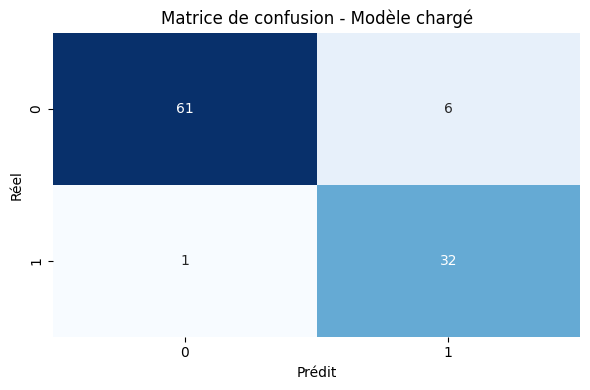

In [58]:
# Matrice de confusion
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Matrice de confusion - {name}")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

/tmp/ipykernel_10997/2209800853.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x="Métrique", y="Score", palette="viridis")


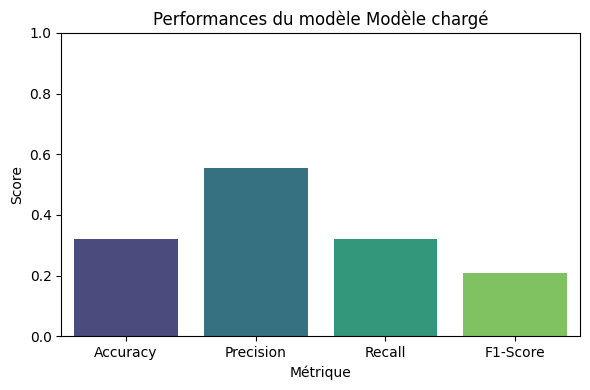

In [38]:
# Barres de comparaison des métriques
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = score(
    y_test, y_pred, average="weighted", zero_division=0
)
metrics_df = pd.DataFrame({
    "Métrique": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [acc, precision, recall, f1]
})
plt.figure(figsize=(6, 4))
sns.barplot(data=metrics_df, x="Métrique", y="Score", palette="viridis")
plt.ylim(0, 1)
plt.title(f"Performances du modèle {name}")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

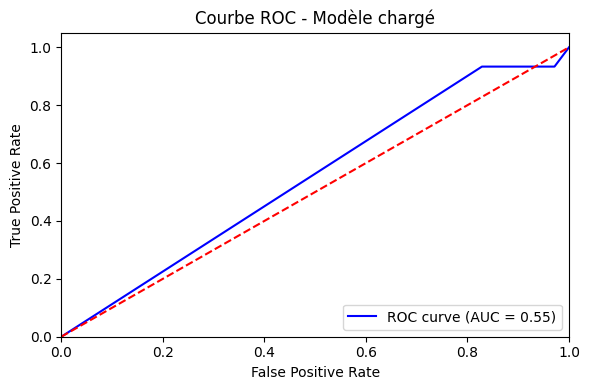

In [39]:
# Courbe ROC
from sklearn.metrics import roc_curve, auc
y_prob = pipe.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Courbe ROC - {name}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

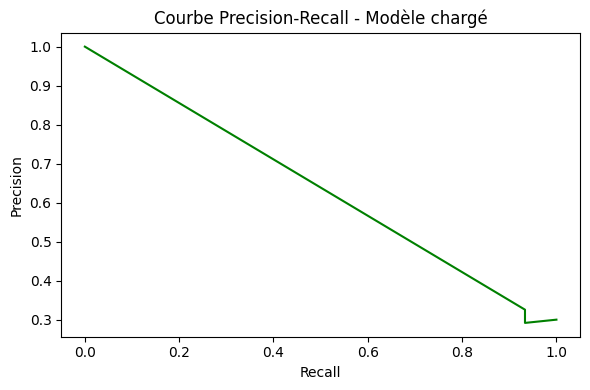

In [40]:
# Courbe precision recall
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Courbe Precision-Recall - {name}")
plt.tight_layout()
plt.show()

=== 1) Répartition science_related vs non_science ===


,Nombre d'exemples,Pourcentage (%)
science_related,,
non_science,765,67.11
science_related,375,32.89



Nombre total d'échantillons : 1140
Classe majoritaire : non_science (765)
Classe minoritaire : science_related (375)
Ratio de déséquilibre : 2.04


/tmp/ipykernel_10997/3191923944.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=parent_counts.index.astype(str), y=parent_counts.values, palette="viridis")


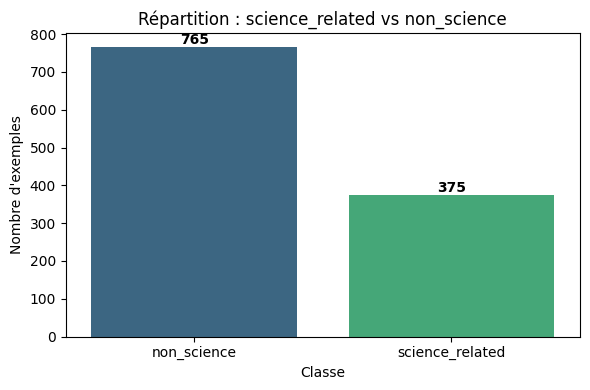

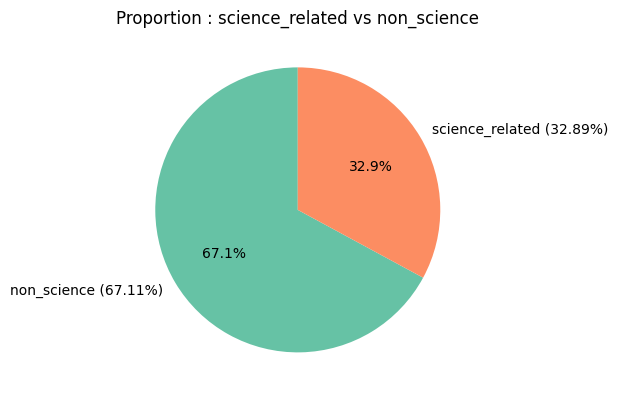


=== 2) Répartition des sous-classes dans science_related ===

Nombre total d'exemples science_related : 375
Classe majoritaire : scientific_claim (263)
Classe minoritaire : scientific_reference (203)
Ratio de déséquilibre : 1.3


/tmp/ipykernel_10997/3191923944.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_counts.index.astype(str), y=sub_counts.values, palette="magma")


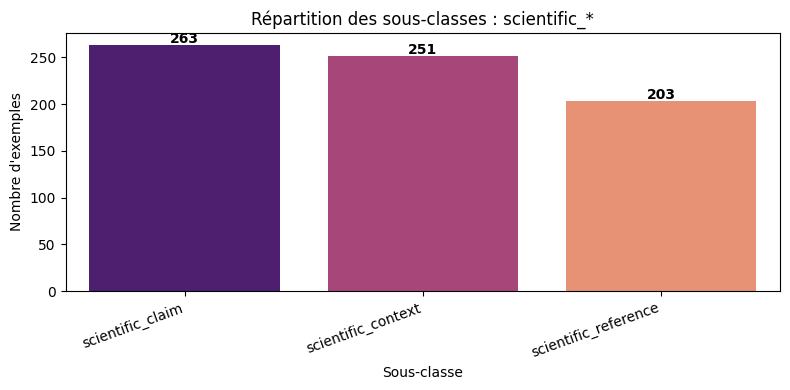


=== Nombre de sous-classes activées par exemple science_related ===


,Nombre d'exemples
1,157
2,94
3,124


In [41]:
# Analyse de l'équilibrage des données

parent_col = "science_related"
subclasses = ["scientific_claim", "scientific_context", "scientific_reference"]

# Vérification des colonnes
cols_needed = [parent_col] + subclasses
missing = [c for c in cols_needed if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes dans df : {missing}")

work_df = df.copy()
for col in cols_needed:
    work_df[col] = work_df[col].fillna(0).astype(int)

# ============================================================
# 1) science_related vs non_science
# ============================================================
print("=== 1) Répartition science_related vs non_science ===")

parent_counts = work_df[parent_col].map({0: "non_science", 1: "science_related"}).value_counts().sort_index()
parent_percent = (parent_counts / parent_counts.sum() * 100).round(2)

parent_stats_df = pd.DataFrame({
    "Nombre d'exemples": parent_counts,
    "Pourcentage (%)": parent_percent
})
display(parent_stats_df)

print(f"\nNombre total d'échantillons : {len(work_df)}")
print(f"Classe majoritaire : {parent_counts.idxmax()} ({parent_counts.max()})")
print(f"Classe minoritaire : {parent_counts.idxmin()} ({parent_counts.min()})")
print(f"Ratio de déséquilibre : {round(parent_counts.max() / parent_counts.min(), 2) if parent_counts.min() > 0 else None}")

plt.figure(figsize=(6, 4))
sns.barplot(x=parent_counts.index.astype(str), y=parent_counts.values, palette="viridis")
plt.title("Répartition : science_related vs non_science")
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples")
for i, v in enumerate(parent_counts.values):
    plt.text(i, v + max(parent_counts.values) * 0.01, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.pie(
    parent_counts.values,
    labels=[f"{idx} ({pct}%)" for idx, pct in zip(parent_counts.index.astype(str), parent_percent)],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", n_colors=len(parent_counts))
)
plt.title("Proportion : science_related vs non_science")
plt.tight_layout()
plt.show()

# ============================================================
# 2) scientific_claim vs scientific_context vs scientific_reference
# ============================================================
print("\n=== 2) Répartition des sous-classes dans science_related ===")

science_df = work_df.loc[work_df[parent_col] == 1].copy()

sub_counts = science_df[subclasses].sum().sort_values(ascending=False)
sub_percent = (sub_counts / sub_counts.sum() * 100).round(2) if sub_counts.sum() > 0 else sub_counts


print(f"\nNombre total d'exemples science_related : {len(science_df)}")
print(f"Classe majoritaire : {sub_counts.idxmax()} ({sub_counts.max()})")
print(f"Classe minoritaire : {sub_counts.idxmin()} ({sub_counts.min()})")
print(f"Ratio de déséquilibre : {round(sub_counts.max() / sub_counts.min(), 2) if sub_counts.min() > 0 else None}")

plt.figure(figsize=(8, 4))
sns.barplot(x=sub_counts.index.astype(str), y=sub_counts.values, palette="magma")
plt.title("Répartition des sous-classes : scientific_*")
plt.xlabel("Sous-classe")
plt.ylabel("Nombre d'exemples")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(sub_counts.values):
    plt.text(i, v + max(sub_counts.values) * 0.01, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# chevauchement des sous-classes
overlap_counts = science_df[subclasses].sum(axis=1).value_counts().sort_index()
print("\n=== Nombre de sous-classes activées par exemple science_related ===")
display(overlap_counts.to_frame(name="Nombre d'exemples"))